In [ ]:
# ==========================
# XGBOOST CROP YIELD MODEL (FULL FIXED VERSION)
# ==========================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pickle



In [ ]:
# ====== LOAD DATASET ======
df = pd.read_csv("crop_Yield.csv")
print("✅ Data Loaded Successfully")
print("Shape before cleaning:", df.shape)

# Drop duplicates if any
df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)

# ====== CONVERT CATEGORICAL COLUMNS ======
cat_cols = df.select_dtypes(include=['object']).columns
print("🧩 Categorical Columns:", list(cat_cols))

# Encode all categorical columns automatically
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

print("✅ Label Encoding Completed")




✅ Data Loaded Successfully
Shape before cleaning: (1000000, 10)
Shape after cleaning: (1000000, 10)
🧩 Categorical Columns: ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']
✅ Label Encoding Completed


In [ ]:
# ====== DEFINE FEATURES AND TARGET ======
X = df.drop(["Yield_tons_per_hectare"], axis=1)
y = df["Yield_tons_per_hectare"]

# ====== SPLIT DATA ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ====== TRAIN XGBOOST REGRESSOR ======
model = xgb.XGBRegressor(
    n_estimators=250,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="rmse" 
)

# Track training progress
eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(
    X_train,
    y_train,
    eval_set=eval_set,
    verbose=False
)

print("✅ Model Training Completed")


✅ Model Training Completed


In [ ]:
# ====== PREDICT ======
y_pred = model.predict(X_test)

# ====== EVALUATE ======
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"📊 Mean Absolute Error: {mae:.4f}")
print(f"📈 R² Score: {r2:.4f}")

📊 Mean Absolute Error: 0.4002
📈 R² Score: 0.9127


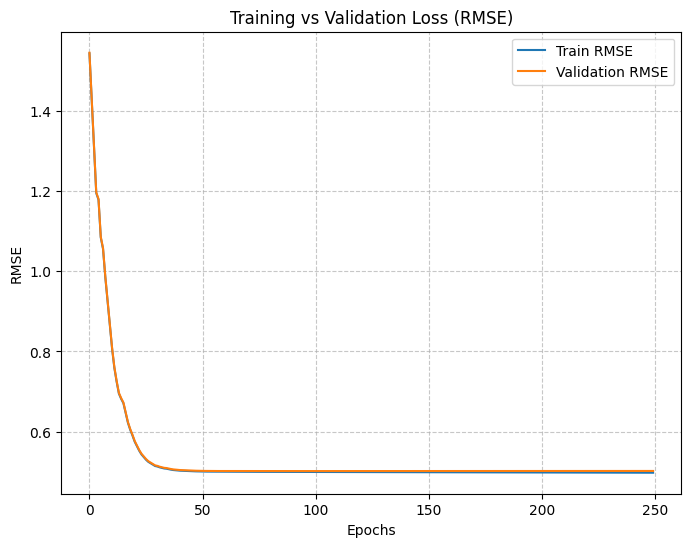

In [ ]:
# ====== 1️⃣ TRAINING & VALIDATION LOSS ======
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

plt.figure(figsize=(8, 6))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE')
plt.plot(x_axis, results['validation_1']['rmse'], label='Validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Training vs Validation Loss (RMSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# ====== SAVE MODEL AND ENCODERS ======
with open("XGBoost_Yield.pkl", "wb") as f:
    pickle.dump(model, f)

with open("LabelEncoders_yield.pkl", "wb") as f:
    pickle.dump(le_dict, f)

print("💾 Model and LabelEncoders saved successfully")

💾 Model and LabelEncoders saved successfully


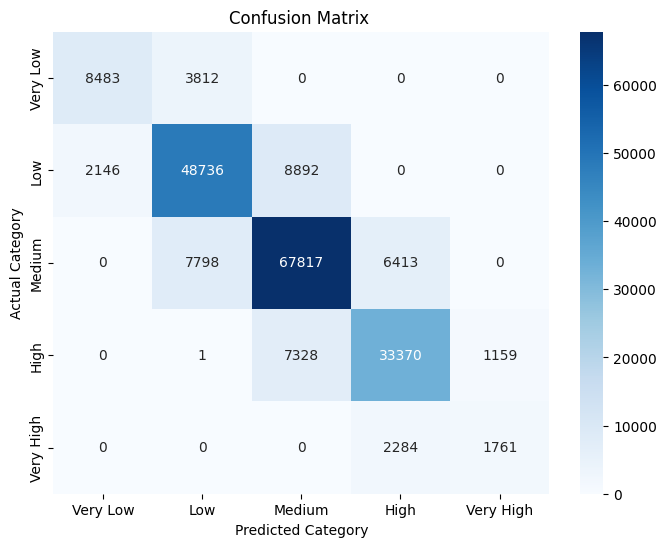

In [ ]:
# ================================
# CONFUSION MATRIX FOR REGRESSION (BINNED)
# ================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Step 1️⃣ – Define yield bins (you can adjust the bin edges)
bins = [-np.inf, 2, 4, 6, 8, np.inf]  # example bins in tons/ha
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

# Step 2️⃣ – Convert actual and predicted values into categories
y_test_binned = pd.cut(y_test, bins=bins, labels=labels)
y_pred_binned = pd.cut(y_pred, bins=bins, labels=labels)

# Step 3️⃣ – Compute confusion matrix
cm = confusion_matrix(y_test_binned, y_pred_binned, labels=labels)

# Step 4️⃣ – Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Confusion Matrix ')
plt.show()
